In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numba
import tqdm
import scipy
import os
import sys
import joblib
import scanpy as sc
import os
import itertools
from itertools import product
from collections import defaultdict
from itertools import combinations
from scipy.stats import mannwhitneyu
from pathlib import Path
from adjustText import adjust_text
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Rectangle
import json

In [2]:
# Calculation functions
import importlib
import sys
import os

from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)

from TwINFER_function_scripts.correlation_analysis_functions import (

    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_cross_correlations,
    identify_actual_directed_edges
)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data,
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

### Plot formatting

In [3]:
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    "fonts/Arial.ttf",
    "fonts/Arial Bold.ttf",
    "fonts/Arial Italic.ttf",
    "fonts/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

# ==== LaTeX + SVG text mode (Illustrator-safe) ====
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18     # x/y labels
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12    # legend text

✔ Loaded font: fonts/Arial.ttf
✔ Loaded font: fonts/Arial Bold.ttf
✔ Loaded font: fonts/Arial Italic.ttf
✔ Loaded font: fonts/Arial Bold Italic.ttf


### Path to data and output folders

In [4]:
data_path = "/home/gzu5140/Keerthana_b1042/grnInference/real_data/Larry_data/"
path_to_plots = f"/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5_myeloid_progenitors/"
os.makedirs(path_to_plots, exist_ok=True)
path_to_plot_data = Path("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/figure_5_myeloid_progenitors_fin/")
path_to_plot_data.mkdir(exist_ok=True)

/home/gzu5140/.conda/envs/twinfer/lib/python3.12/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


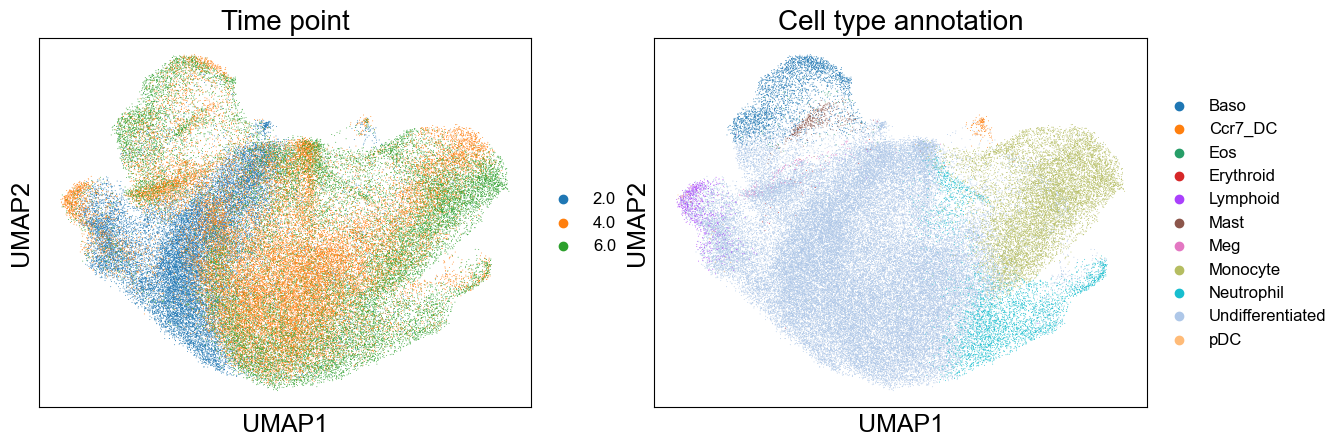

In [5]:
#Load the h5ad file
# Define the full path to the data file
file_path = f'{data_path}LSK_d2_d4_d6.h5ad'
adata = sc.read_h5ad(file_path)
adata.obs_names_make_unique()
# Plot UMAP
sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])

### Genes of interest
- Neutrophil DEG from LARRY
- Monocyte DEG from LARRY
- TF involved in hematopoiesis from the 2011 paper

In [6]:
gene_list_Neutrophil = ['Muc13', 'Srgn', 'Ccl9', 'Plac8', 'Snrpf','Prtn3','Elane', 'Igfbp4', 'Ap3s1', 'Ctsg'] #Neutrophil
gene_list_Monocyte = ['Rbms1', 'Tuba1b','Sirpa', 'Ttf1', 'H3f3b', 'Set', 'Tk1', 'Fkbp4', 'Hspd1', 'Emb'] #Monocyte
gene_list_Regulator_TF = ['Gata1', 'Gata2', 'Gfi1', 'Fli1', 'Spi1', 'Tal1',  'Cebpa', 'Jun', 'Egr1', 'Nab2', 'Klf1', 'Zfpm1'] #TF involved in hematopoiesis regulation
gene_list_Pertubation = ['Brd9', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Gps2', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']

In [7]:
#Check that all of these genes are present in the dataset (since sometimes they have alternate names. E.g. Pu1 is names Spi1)
gene_list_check = gene_list_Neutrophil + gene_list_Monocyte + gene_list_Regulator_TF + gene_list_Pertubation

all_genes = {g.lower() for g in adata.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)

print("❌ Not found in dataset", not_found)

Found 73 genes out of 73
✅ Found gene(s): ['muc13', 'srgn', 'ccl9', 'plac8', 'snrpf', 'prtn3', 'elane', 'igfbp4', 'ap3s1', 'ctsg', 'rbms1', 'tuba1b', 'sirpa', 'ttf1', 'h3f3b', 'set', 'tk1', 'fkbp4', 'hspd1', 'emb', 'gata1', 'gata2', 'gfi1', 'fli1', 'spi1', 'tal1', 'cebpa', 'jun', 'egr1', 'nab2', 'klf1', 'zfpm1', 'brd9', 'wdr82', 'smarcd2', 'smarcd1', 'bcl11a', 'stag2', 'setd1b', 'gps2', 'men1', 'chd4', 'kmt2a', 'smc2', 'phf10', 'cbx3', 'crebbp', 'hdac3', 'setdb2', 'ehmt2', 'mbd2', 'setdb1', 'rbbp4', 'hdac1', 'mbd3', 'rcor1', 'atf7ip', 'hmgxb4', 'carm1', 'prmt5', 'cebpa', 'ash1l', 'smarcb1', 'ezh2', 'chaf1a', 'prmt1', 'ehmt1', 'smc4', 'smc3', 'chmp2a', 'kdm6a', 'spi1', 'gata2']
❌ Not found in dataset []


In [8]:
#Gene set to use for current analysis
gene_set_name = "Regulator_TF" #For Neutrohils, modify this to Neutrophil
curr_gene_list = gene_list_Regulator_TF #For neutrophil, modify this to gene_list_Neutrophil
gene_subset = [s + '_mRNA' for s in curr_gene_list]

## Prepare the data needed for analysis

- Undifferentiated cells to identify DEG genes before differentiation
- All cells present at each time point to calculate gene correlations
- Twin/Clonal pairs at each time point and across timepoints (t1 cells can be either all cells or only undifferentiated cells)
- Random pairs of cells at each time point

In [9]:
t1 = 2
t2 = 4
t3 = 6

In [10]:
#Subset the data into different time points - includes both barcoded and not barcoded cells (hence, all)
adata.obs['cell_id'] = adata.obs.index
adata_t1_all = adata[(adata.obs['Time point'] == t1)].copy()
adata_t2_all = adata[(adata.obs['Time point'] == t2)].copy()
adata_t3_all = adata[(adata.obs['Time point'] == t3)].copy()

In [11]:
# All cells at time t1 to calculate gene correlation
def make_all_cells_table(adata_t, timepoint, gene_subset, curr_gene_list):
    df = pd.DataFrame({
        'clone_id': adata_t.obs['clone_id'].values,
        'cell_id': adata_t.obs['cell_id'].values,
    })

    # dummy but consistent fields to match twin format
    df['pair_id'] = df['cell_id'].astype(str) + f"_single_{timepoint}"
    df['replicate'] = 1
    df['time_step'] = timepoint

    # add expression
    df[gene_subset] = adata_t[df.cell_id, curr_gene_list].X.toarray()

    return df

gene_subset = [s + '_mRNA' for s in curr_gene_list]
t1_data_all_cells = make_all_cells_table(
    adata_t1_all, t1, gene_subset, curr_gene_list
)
t2_data_all_cells = make_all_cells_table(
    adata_t2_all, t2, gene_subset, curr_gene_list
)
t3_data_all_cells = make_all_cells_table(
    adata_t3_all, t3, gene_subset, curr_gene_list
)

In [12]:
#Identifying barcoded cells at time t1
adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()
adata_t1_clones_undiff = adata_t1[adata_t1.obs['Cell type annotation'] == 'Undifferentiated']

# Print the results
print(f"Number of barcoded cells: {adata_t1.shape[0]}")
print(f"Number of undifferentiated barcoded cells: {adata_t1_clones_undiff.shape[0]}")

adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()

Number of barcoded cells: 2809
Number of undifferentiated barcoded cells: 2770


# Identify DEG

### Assign undifferentiated cells (day 2) cell-types based on future (day 4 and day 6) clonal cells' cell-type

In [13]:
# Initialize dictionary to store cell type counts and percentages for each clone_id
clone_cell_type = {}

# Loop through each unique clone_id
for clone_id in adata_t1_clones_undiff.obs.clone_id.unique():
    # Get unique cell types for t2 and t3 as lists
    unique_t2_cell_types = adata_t2[adata_t2.obs.clone_id == clone_id].obs['Cell type annotation'].unique().tolist()
    unique_t3_cell_types = adata_t3[adata_t3.obs.clone_id == clone_id].obs['Cell type annotation'].unique().tolist()

    # Concatenate the lists and convert to a set (to avoid duplicates)
    cell_type = set(unique_t2_cell_types + unique_t3_cell_types)
    if len(cell_type) < 1:
        continue

    # Get the number of cells for each cell type at t2 and t3
    t2_cell_counts = adata_t2[adata_t2.obs.clone_id == clone_id].obs['Cell type annotation'].value_counts()
    t3_cell_counts = adata_t3[adata_t3.obs.clone_id == clone_id].obs['Cell type annotation'].value_counts()

    # Initialize dictionary to store counts and percentages
    cell_type_info = {}

    # Count and calculate percentages for t2
    total_cells_t2 = len(adata_t2[adata_t2.obs.clone_id == clone_id])
    for cell in cell_type:
        t2_count = t2_cell_counts.get(cell, 0)
        t2_percentage = (t2_count / total_cells_t2) * 100 if total_cells_t2 > 0 else 0
        cell_type_info[cell] = {'t2_count': t2_count, 't2_percentage': t2_percentage}

    # Count and calculate percentages for t3
    total_cells_t3 = len(adata_t3[adata_t3.obs.clone_id == clone_id])
    for cell in cell_type:
        t3_count = t3_cell_counts.get(cell, 0)
        t3_percentage = (t3_count / total_cells_t3) * 100 if total_cells_t3 > 0 else 0
        if cell in cell_type_info:
            cell_type_info[cell].update({'t3_count': t3_count, 't3_percentage': t3_percentage})
        else:
            cell_type_info[cell] = {'t3_count': t3_count, 't3_percentage': t3_percentage}

    # Store the information in the dictionary
    clone_cell_type[clone_id] = cell_type_info

# Convert the dictionary into a pandas DataFrame for easier inspection
cell_type_df = pd.DataFrame.from_dict({(clone_id, cell_type): values
                                       for clone_id, clone_info in clone_cell_type.items()
                                       for cell_type, values in clone_info.items()},
                                      orient='index')

# Display the DataFrame
print(cell_type_df)

                       t2_count  t2_percentage  t3_count  t3_percentage
94   Undifferentiated         2          100.0         0            0.0
5827 Monocyte                 1          100.0         0            0.0
216  Eos                      1          100.0         0            0.0
4676 Undifferentiated         2          100.0         1          100.0
5412 Undifferentiated         1          100.0         0            0.0
...                         ...            ...       ...            ...
3729 Monocyte                 1          100.0         1          100.0
441  Undifferentiated         1          100.0         0            0.0
3227 Monocyte                 0            0.0         7           87.5
     Undifferentiated         0            0.0         1           12.5
3065 Undifferentiated         2          100.0         2          100.0

[1619 rows x 4 columns]


Index names: [None, None]


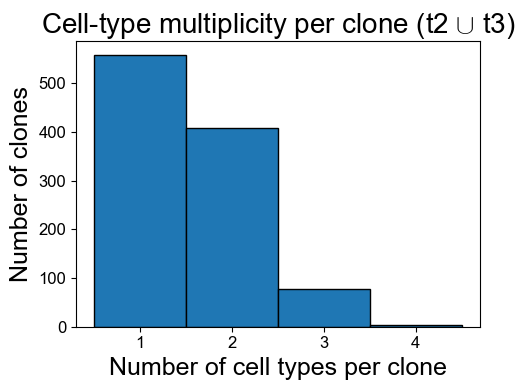

In [14]:
# --------------------------------------------------
# 0. Sanity check: confirm index structure
# --------------------------------------------------
print("Index names:", cell_type_df.index.names)
# Expected: ['clone_id', 'cell_type']

# --------------------------------------------------
# 1. Count cell-type multiplicity per clone (t2 ∪ t3)
# --------------------------------------------------
n_cell_types_per_clone = (
    cell_type_df
    .query("(t2_percentage > 0) or (t3_percentage > 0)")
    .groupby(level=0)   # level 0 = clone_id
    .size()             # one row per cell type → count = multiplicity
)

# --------------------------------------------------
# 24. Histogram
# --------------------------------------------------
plt.figure(figsize=(5, 4))
plt.hist(
    n_cell_types_per_clone,
    bins=range(1, n_cell_types_per_clone.max() + 2),
    align="left",
    edgecolor="black"
)
plt.xlabel("Number of cell types per clone")
plt.ylabel("Number of clones")
plt.title(r"Cell-type multiplicity per clone (t2 $\cup$ t3)")
plt.tight_layout()
plt.show()


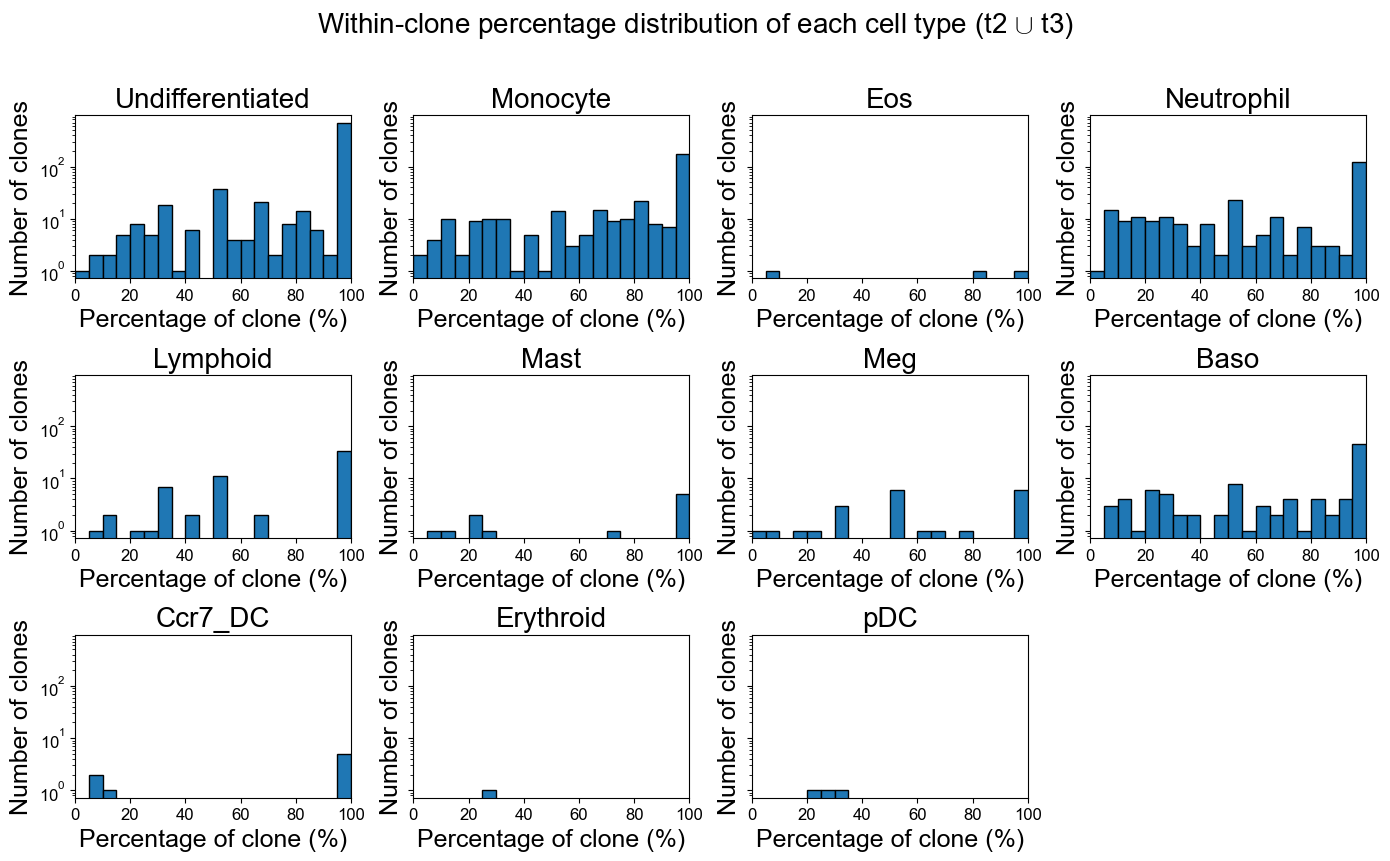

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Assumptions
# --------------------------------------------------
# cell_type_df:
#   MultiIndex (clone_id, cell_type)
#   columns: t2_percentage, t3_percentage
#
# Definition:
#   For each cell type, use the percentage at the timepoint
#   where it occurs (t2 or t3). If it occurs at both, take max.

# --------------------------------------------------
# Get cell types
# --------------------------------------------------
cell_types = cell_type_df.index.get_level_values(1).unique()

# --------------------------------------------------
# Set up subplot grid
# --------------------------------------------------
n_types = len(cell_types)
n_cols = 4
n_rows = int(np.ceil(n_types / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 2.8 * n_rows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

# --------------------------------------------------
# Loop over cell types
# --------------------------------------------------
for ax, ct in zip(axes, cell_types):

    df_ct = cell_type_df.xs(ct, level=1)

    # Use the percentage where the cell type occurs
    pct = df_ct[["t2_percentage", "t3_percentage"]].max(axis=1)

    # Keep only clones where it actually appears
    pct = pct[pct > 0]

    ax.hist(
        pct,
        bins=np.linspace(0, 100, 21),
        edgecolor="black"
    )

    ax.set_title(ct)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentage of clone (%)")
    ax.set_ylabel("Number of clones")
    ax.set_yscale('log')
# Turn off unused axes
for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle(
    r"Within-clone percentage distribution of each cell type (t2 $\cup$ t3)",
    y=1.02, fontsize = 20
)

plt.tight_layout()
plt.show()


In [14]:
clone_dominant_cell_type = {}
clone_cell_type_composition = {}
count = 0
for clone_id, cell_type_info in clone_cell_type.items():

    # --- compute max at each time ---
    max_t2 = max(info["t2_percentage"] for info in cell_type_info.values())
    max_t3 = max(info["t3_percentage"] for info in cell_type_info.values())

    dom_t2 = sorted([
        ct for ct, info in cell_type_info.items()
        if info["t2_percentage"] == max_t2
    ])

    dom_t3 = sorted([
        ct for ct, info in cell_type_info.items()
        if info["t3_percentage"] == max_t3
    ])


    # --- choose timepoint ---
    if max_t3 > max_t2:
        chosen_types = dom_t3
        time_key = "t3_percentage"

    elif max_t2 > max_t3:
        # t2 wins unless it is purely Undifferentiated
        if dom_t2 == ["Undifferentiated"] and max_t3 > 0:
            count +=1
            chosen_types = dom_t3
            time_key = "t3_percentage"
        else:
            chosen_types = dom_t2
            time_key = "t2_percentage"

    else:  # equal max
        chosen_types = dom_t3
        time_key = "t3_percentage"

    # --- resolve ties ---
    if len(chosen_types) > 1:
        non_undiff = [ct for ct in chosen_types if ct != "Undifferentiated"]
        if len(non_undiff) > 0:
            chosen_types = non_undiff
        # else: keep Undifferentiated

    # --- final assignment (SCALAR ONLY) ---
    dominant_type = chosen_types[0] if len(chosen_types) > 0 else None
    clone_dominant_cell_type[clone_id] = dominant_type

    # --- composition string ---
    composition_parts = []
    for ct, info in cell_type_info.items():
        pct = info[time_key]
        if pct > 0:
            composition_parts.append(f"{ct}: {pct:.0f}%")

    clone_cell_type_composition[clone_id] = ", ".join(composition_parts)

# Now, assign the dominant cell type(s) to each clone in adata.obs
adata_t1_clones_undiff.obs["dominant_cell_type"] = None
adata_t1_clones_undiff.obs["cell_type_composition"] = None

for clone_id, dom_type in clone_dominant_cell_type.items():
    adata_t1_clones_undiff.obs.loc[
        adata_t1_clones_undiff.obs.clone_id == clone_id,
        "dominant_cell_type"
    ] = dom_type

    adata_t1_clones_undiff.obs.loc[
        adata_t1_clones_undiff.obs.clone_id == clone_id,
        "cell_type_composition"
    ] = clone_cell_type_composition[clone_id]

# How many got None?
print(
    adata_t1_clones_undiff.obs["dominant_cell_type"]
    .isna()
    .sum()
)
print(count)

/tmp/ipykernel_3165961/4106201928.py:61: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_t1_clones_undiff.obs["dominant_cell_type"] = None


1305
194


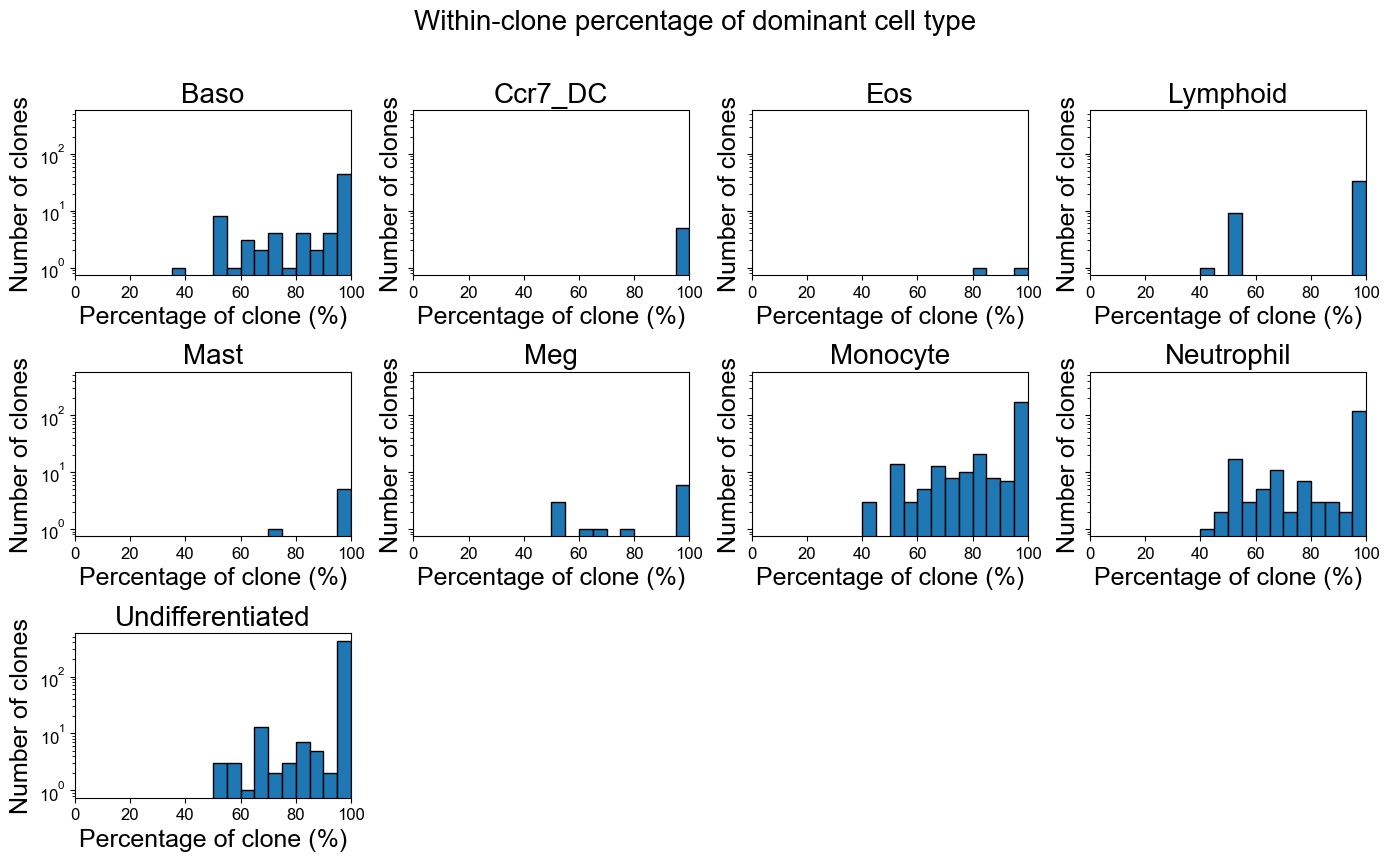

In [17]:
# --------------------------------------------------
# Get clone -> dominant cell type mapping
# --------------------------------------------------
clone_to_dom = (
    adata_t1_clones_undiff.obs
    .dropna(subset=["dominant_cell_type"])
    .drop_duplicates(subset=["clone_id"])
    .set_index("clone_id")["dominant_cell_type"]
)

# --------------------------------------------------
# Get list of dominant cell types
# --------------------------------------------------
dominant_cell_types = sorted(clone_to_dom.unique())

# --------------------------------------------------
# Set up subplot grid
# --------------------------------------------------
n_types = len(dominant_cell_types)
n_cols = 4
n_rows = int(np.ceil(n_types / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 2.8 * n_rows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

# --------------------------------------------------
# Loop over dominant cell types
# --------------------------------------------------
for ax, ct in zip(axes, dominant_cell_types):

    # clones where this cell type is dominant
    clones_ct = clone_to_dom[clone_to_dom == ct].index

    # SAFE extraction (no KeyError)
    df_ct_all = cell_type_df.xs(ct, level=1, drop_level=False)
    df_ct = df_ct_all.loc[
        df_ct_all.index.get_level_values(0).isin(clones_ct)
    ]

    if df_ct.empty:
        ax.axis("off")
        continue

    # dominant percentage
    pct = df_ct[["t2_percentage", "t3_percentage"]].max(axis=1)

    ax.hist(
        pct,
        bins=np.linspace(0, 100, 21),
        edgecolor="black"
    )

    ax.set_title(ct)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentage of clone (%)")
    ax.set_ylabel("Number of clones")
    ax.set_yscale("log")

# Turn off unused axes
for ax in axes[len(dominant_cell_types):]:
    ax.axis("off")

plt.suptitle(
    "Within-clone percentage of dominant cell type",
    y=1.02, fontsize = 20
)

plt.tight_layout()
plt.show()


In [15]:
# Get unique cell types INCLUDING None
cell_type_list = adata_t1_clones_undiff.obs['dominant_cell_type'].unique()

# Print the total number of cells
print(f"Number of cells: {adata_t1_clones_undiff.shape[0]}")

# Print the number of cell types and list them
print(f"Number of cell types (including None): {len(cell_type_list)}")
print(f"Cell types: {cell_type_list}")

# Count number of cells per dominant cell type INCLUDING None
cell_type_counts = (
    adata_t1_clones_undiff.obs['dominant_cell_type']
    .value_counts(dropna=False)
)

# Print counts
for cell_type, count in cell_type_counts.items():
    print(f"{cell_type}: {count}")

Number of cells: 2770
Number of cell types (including None): 10
Cell types: [None 'Undifferentiated' 'Monocyte' 'Eos' 'Neutrophil' 'Lymphoid' 'Meg'
 'Baso' 'Mast' 'Ccr7_DC']
None: 1305
Undifferentiated: 620
Monocyte: 384
Neutrophil: 251
Baso: 110
Lymphoid: 64
Meg: 16
Ccr7_DC: 8
Eos: 6
Mast: 6


## Filter out known non-myeloid progenitors

In [16]:
lymphoid_cells = ['Lymphoid']
adata_t1_clones_undiff_filter = adata_t1_clones_undiff[~adata_t1_clones_undiff.obs['dominant_cell_type'].isin(lymphoid_cells)]

## Volcano plot

In [17]:
def volcano_plot(
    adata,
    groupby,
    group,
    genes,
    pval_threshold=0.05,
    gene_list_Neutrophil=[],
    gene_list_monocyte=[],
    gene_list_ubi_exp=[]
    ):

    # -----------------------------
    # Subset data
    # -----------------------------
    adata_group1 = adata[adata.obs[groupby] == group]
    adata_group2 = adata[adata.obs[groupby] != group]

    logfc_list, pval_list, gene_group_list = [], [], []
    mean_g1_list, mean_g2_list = [], []

    for gene in genes:
        expr_group1 = np.expm1(adata_group1[:, gene].X.toarray()).flatten()
        expr_group2 = np.expm1(adata_group2[:, gene].X.toarray()).flatten()

        mean_group1 = np.mean(expr_group1)
        mean_group2 = np.mean(expr_group2)

        logfc = np.log2((mean_group1 + 1) / (mean_group2 + 1))
        logfc_list.append(logfc)
        mean_g1_list.append(mean_group1)
        mean_g2_list.append(mean_group2)

        _, pval = mannwhitneyu(expr_group1, expr_group2, alternative="two-sided")
        pval_list.append(pval)

        if gene in gene_list_Neutrophil:
            gene_group_list.append("Neutrophil")
        elif gene in gene_list_monocyte:
            gene_group_list.append("Monocyte")
        elif gene in gene_list_ubi_exp:
            gene_group_list.append("Regulatory TF")
        else:
            gene_group_list.append("Other")

    # -----------------------------
    # Results DataFrame
    # -----------------------------
    df_results = pd.DataFrame({
        "gene": genes,
        "mean_g1": mean_g1_list,
        "mean_g2": mean_g2_list,
        "logFC": logfc_list,
        "pval": pval_list,
        "gene_group": gene_group_list
    })

    df_results["neg_log10_pval"] = -np.log10(df_results["pval"] + 1e-10)
    df_results["significant"] = df_results["pval"] <= pval_threshold

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(8, 6))

    # Non-significant (grey)
    sns.scatterplot(
        data=df_results[~df_results["significant"]],
        x="logFC",
        y="neg_log10_pval",
        style="gene_group",
        markers={
            "Neutrophil": "s",
            "Monocyte": "D",
            "Regulatory TF": "^",
            "Other": "X"
        },
        color="lightgray",
        edgecolor=None,
        legend=False,
        clip_on=False,
        ax=ax
    )

    # Significant (colored)
    sns.scatterplot(
        data=df_results[df_results["significant"]],
        x="logFC",
        y="neg_log10_pval",
        hue="gene_group",
        style="gene_group",
        palette={
            "Neutrophil": "#56B4E9",
            "Monocyte": "#CC79A7",
            "Regulatory TF": "#009E73",
            "Other": "gray"
        },
        markers={
            "Neutrophil": "s",
            "Monocyte": "D",
            "Regulatory TF": "^",
            "Other": "X"
        },
    edgecolor='none', 
    linewidth=0,       
    clip_on=False,
    ax=ax
    )

    # -----------------------------
    # Text labels (no clipping)
    # -----------------------------
    texts = []
    for _, row in df_results[df_results["significant"]].iterrows():
        texts.append(
            ax.text(
                row["logFC"],
                row["neg_log10_pval"],
                row["gene"],
                fontsize=14,
                clip_on=False
            )
        )

    adjust_text(
    texts,
    ax=ax,
    move_only={'text': 'xy'},  
    expand_text=(1.1, 1.1),    
    expand_points=(1.0, 1.0),  
    force_text=(0.1, 0.4),      
    )

    # -----------------------------
    # Threshold line
    # -----------------------------
    ax.axhline(
        y=-np.log10(pval_threshold),
        color="green",
        linestyle="--",
        clip_on=False
    )

    # -----------------------------
    # Styling
    # -----------------------------
    sns.despine(ax=ax, right=True, top=True)
    ax.set_title(f"{group} vs rest")
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 p-value")

    ax.legend(
        title="Gene Groups",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False
    )
    plt.show()

    return df_results

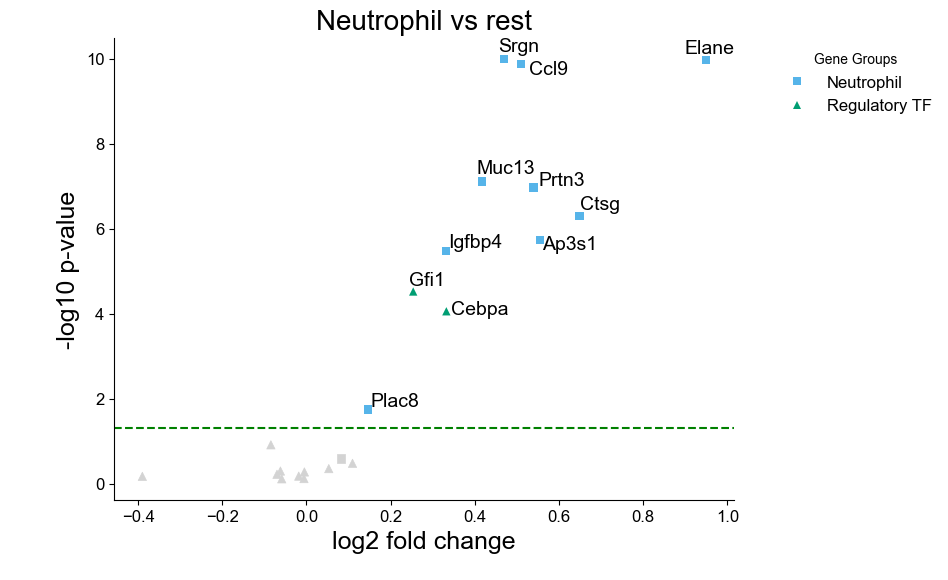

In [18]:
df_volcano_plot = {}
genes = gene_list_Neutrophil  + gene_list_Regulator_TF
cell_type_list = ["Neutrophil"]
for cell_type in cell_type_list:
  if cell_type == "None":
    continue
  df_volcano_plot[cell_type] = volcano_plot(adata_t1_clones_undiff_filter, groupby='dominant_cell_type', group=cell_type, genes = genes, pval_threshold=0.05, gene_list_Neutrophil=gene_list_Neutrophil, gene_list_ubi_exp=gene_list_Regulator_TF)
# for cell_type in df_volcano_plot.keys():
#     df = df_volcano_plot[cell_type]
    # df.to_csv(f"{path_to_plot_data}/volcano_plot_{cell_type}_myeloid.csv")

In [17]:
#Twin pairs at each time point and across time point
use_undifferentiated = True
if use_undifferentiated:
    adata_t1 = adata_t1_clones_undiff_filter.copy()
else:
    adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()

adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()

#Remove any lymphoid-lineage cells
lymphoid_cells = ['Lymphoid', 'pDC']
adata_t2 = adata_t2[~adata_t2.obs['Cell type annotation'].isin(lymphoid_cells)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3[~adata_t3.obs['Cell type annotation'].isin(lymphoid_cells)].copy()

# Save cell IDs in .obs
adata_t1.obs['cell_id'] = adata_t1.obs_names
adata_t2.obs['cell_id'] = adata_t2.obs_names
adata_t3.obs['cell_id'] = adata_t3.obs_names

# Pick subset of genes
gene_subset = [s + '_mRNA' for s in curr_gene_list]

# Create tables for t1, t2 and t3 twin pairs
for adata_t, timepoint in zip([adata_t1,adata_t2,adata_t3], ['t1','t2', 't3']):
    rows = []
    for clone_id, group in adata_t.obs.groupby('clone_id'):
        cells = group['cell_id'].tolist()
        pair_counter = 0
        for c1, c2 in itertools.combinations(cells, 2):
            pair_id = f"{clone_id}_p{pair_counter}_{timepoint}"
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c1,
                'replicate': 1
            })
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c2,
                'replicate': 2
            })
            pair_counter += 1

    if timepoint == 't1':
        t1_data = pd.DataFrame(rows)
    elif timepoint == 't2':
        t2_data = pd.DataFrame(rows)
    else:
        t3_data = pd.DataFrame(rows)

t1_data['time_step'] = np.repeat(t1, len(t1_data))
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t3_data['time_step'] = np.repeat(t3, len(t3_data))

t1_data[gene_subset] = adata_t1[t1_data.cell_id, curr_gene_list].X.toarray()
t2_data[gene_subset] = adata_t2[t2_data.cell_id, curr_gene_list].X.toarray()
t3_data[gene_subset] = adata_t3[t3_data.cell_id, curr_gene_list].X.toarray()

# ### Create tables for across t twin pairs
across_t_clones = list(set(adata_t1.obs.clone_id).intersection(adata_t2.obs.clone_id))
adata_t1_sub = adata_t1[adata_t1.obs.clone_id.isin(across_t_clones)]
adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]

rows_t1 = []
rows_t2 = []
for clone_id in across_t_clones:
    cells_t1 = adata_t1_sub[adata_t1_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    cells_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    pair_counter = 0
    for cell_t1 in cells_t1:
        for cell_t2 in cells_t2:
            pair_id = f"{clone_id}_p{pair_counter}_across_t"
            rows_t1.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t1,
                'replicate': 1,
                'time_step': t1
            })
            rows_t2.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t2,
                'replicate': 2,
                'time_step': t2
            })

            pair_counter += 1

across_t_data_t1 = pd.DataFrame(rows_t1)
across_t_data_t2 = pd.DataFrame(rows_t2)

across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1.cell_id, curr_gene_list].X.toarray()
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, curr_gene_list].X.toarray()
across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data_t1.shape[0])}")

Number of t1 twins: 1547
Number of t2 twins: 7471
Number of t3 twins: 92789
Number of across t twins: 2879


## Comparing the twin vs random-pair PCA distance

### Helper functions

In [20]:
# ============================
#   1. Distance computation
# =============
# ===============
def compute_distances(adata):
    """
    Compute pairwise transcriptomic distances assuming cells are sorted
    in twin order: (cell0_A, cell0_B, cell1_A, cell1_B, ...)
    and that each consecutive pair belongs to the same clone.
    """
    pca = adata.obsm['X_pca']
    clone_ids = adata.obs['clone_id'].values

    # sanity check: even number of cells
    if pca.shape[0] % 2 != 0:
        raise ValueError("Number of cells must be even for twin pairing.")

    # check clone_id matching
    clone_left  = clone_ids[::2]
    clone_right = clone_ids[1::2]

    if not np.all(clone_left == clone_right):
        bad = np.where(clone_left != clone_right)[0]
        raise ValueError(
            f"Found {len(bad)} twin pairs with mismatched clone_id. "
            f"First few bad indices: {bad[:5]}"
        )

    # compute distances
    deltas = pca[::2] - pca[1::2]
    return np.linalg.norm(deltas, axis=1)


# ============================
#   2. Significance symbols
# ============================
def get_significance_symbol(pval):
    if pval > 0.05:
        return 'ns'
    elif pval <= 0.0001:
        return '****'
    elif pval <= 0.001:
        return '***'
    elif pval <= 0.01:
        return '**'
    else:
        return '*'

# ============================
#   3. Stat annotation for boxplots
# ============================
def add_stat_annotation(ax, category_a, category_b, label, subset,
                        y_offset=0.05, level=0):
    """
    Draws a significance bracket ABOVE vertical boxplots with clip turned OFF.
    """

    # X-axis category names
    xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]

    if category_a not in xticklabels or category_b not in xticklabels:
        return

    x1 = xticklabels.index(category_a)
    x2 = xticklabels.index(category_b)
    x_min, x_max = min(x1, x2), max(x1, x2)

    # Height for bracket
    ymax = subset['Transcriptomic distance [a.u.]'].max()
    h = ymax * (1 + y_offset + level * 0.12)

    # Bracket line (no clipping)
    ax.plot(
        [x_min, x_min, x_max, x_max],
        [h, h * 1.05, h * 1.05, h],
        lw=1.5,
        color='black',
        clip_on=False
    )

    # Label (no clipping)
    ax.text(
        (x_min + x_max) / 2,
        h * 1.12,
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        clip_on=False
    )

def plot_vertical_boxplots(df_distances, save_dir = None):

    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    # plt.subplots_adjust(top=0.83)  # Ensure title + brackets never clip

    timepoints = ['Day 2', 'Day 4', 'Day 6']

    for ax, timepoint in zip(axes, timepoints):

        subset = df_distances[df_distances['timepoint'] == timepoint]

        # -----------------------------
        # Vertical boxplot
        # -----------------------------
        bp = sns.boxplot(
            data=subset,
            x='pair_type',
            y='Transcriptomic distance [a.u.]',
            hue='pair_type',
            palette={'clonal pairs': 'lightgray', 'random pairs': 'gray'},
            ax=ax
        )

        # Disable clipping for every boxplot artist
        for artist in ax.artists + ax.lines:
            artist.set_clip_on(False)

        sns.despine(right=True, top=True, ax=ax)

        ax.set_xlabel('')
        ax.set_ylabel('transcriptomic distance [a.u.]')
        ax.set_title(timepoint, pad=30)  # higher title
        ax.set_ylim(0,62)
        # -----------------------------
        # Mann-Whitney U-test
        # -----------------------------
        clonal = subset[subset['pair_type'] == 'clonal pairs']['Transcriptomic distance [a.u.]']
        random = subset[subset['pair_type'] == 'random pairs']['Transcriptomic distance [a.u.]']

        _, pval = mannwhitneyu(clonal, random, alternative='two-sided')
        label = get_significance_symbol(pval)
        # # -----------------------------
        # # Add significance bracket
        # # -----------------------------
        add_stat_annotation(
            ax=ax,
            category_a='clonal pairs',
            category_b='random pairs',
            label=label,
            subset=subset,
            y_offset=0.05,
            level=0
        )


    # Legend outside (no clipping)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist_day_2.svg'),
                    format='svg',
                    facecolor='none', edgecolor='none', transparent=True)
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist_day_2.pdf'),
                    format='pdf',
                    facecolor='none', edgecolor='none', transparent=True)

### Calculate the distances

In [28]:
# Compute distances in PC space
distances_t1 = compute_distances(adata_t1[t1_data.cell_id])
distances_t2 = compute_distances(adata_t2[t2_data.cell_id])
distances_t3 = compute_distances(adata_t3[t3_data.cell_id])

distances_across_t = adata_t1[across_t_data_t1.cell_id].obsm['X_pca'] - adata_t2[across_t_data_t2.cell_id].obsm['X_pca']
distances_across_t = np.linalg.norm(distances_across_t, axis=1)

# Random
np.random.seed(42)

def random_distances(adata, n_pairs):
    idx = np.arange(adata.n_obs)
    pairs = np.random.choice(idx, size=(n_pairs, 2), replace=True)
    pairs = pairs[pairs[:, 0] != pairs[:, 1]]
    while pairs.shape[0] < n_pairs:
        extra = np.random.choice(idx, size=(n_pairs - pairs.shape[0], 2), replace=True)
        extra = extra[extra[:, 0] != extra[:, 1]]
        pairs = np.vstack([pairs, extra])
    return np.linalg.norm(adata.obsm["X_pca"][pairs[:, 0]] - adata.obsm["X_pca"][pairs[:, 1]], axis=1)

distances_random_t1 = random_distances(adata_t1, len(distances_t1))
distances_random_t2 = random_distances(adata_t2, len(distances_t2))
distances_random_t3 = random_distances(adata_t3, len(distances_t3))



# Create dataframe for plotting
df_distances = pd.DataFrame({
    'Transcriptomic distance [a.u.]': np.concatenate([distances_t1, distances_t2, distances_t3,
                                distances_random_t1, distances_random_t2, distances_random_t3]),
    'pair_type': (['clonal pairs'] * len(distances_t1) +
                  ['clonal pairs'] * len(distances_t2) +
                  ['clonal pairs'] * len(distances_t3) +
                  ['random pairs'] * len(distances_random_t1) +
                  ['random pairs'] * len(distances_random_t2) +
                  ['random pairs'] * len(distances_random_t3)),
    'timepoint': (['Day 2'] * len(distances_t1) +
                  ['Day 4'] * len(distances_t2) +
                  ['Day 6'] * len(distances_t3) +
                  ['Day 2'] * len(distances_random_t1) +
                  ['Day 4'] * len(distances_random_t2) +
                  ['Day 6'] * len(distances_random_t3))
})

### Plot and save the boxplots

In [ ]:
plot_vertical_boxplots(df_distances, save_dir = None)
# df_distances.to_csv(f"{path_to_plot_data}twin_vs_random_dist.csv")

# Infer with TwINFER

In [18]:
# Drop column clone_id and rename pair_id to clone_id
t1_data.drop(columns=['clone_id'], inplace=True)
t1_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t2_data.drop(columns=['clone_id'], inplace=True)
t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t3_data.drop(columns=['clone_id'], inplace=True)
t3_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

across_t_data.drop(columns=['clone_id'], inplace=True)
across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t1_clones = t1_data.clone_id.values
t2_clones = t2_data.clone_id.values
t3_clones = t3_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t1_twins = t1_data
t2_twins = t2_data
t3_twins = t3_data

# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = across_t_data[across_t_data.time_step == t1]
across_t_twin2 = across_t_data[across_t_data.time_step == t2]

# Reset index for cleanliness
t1_twins = t1_twins.reset_index(drop=True)
t2_twins = t2_twins.reset_index(drop=True)
t3_twins = t3_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)

all_t1_measurements = (
    pd.concat([t1_twins, across_t_twin1], ignore_index=True)
      .drop_duplicates(subset="cell_id", keep="first")
)

all_t2_measurements = (
    pd.concat([t2_twins, across_t_twin2], ignore_index=True)
      .drop_duplicates(subset="cell_id", keep="first")
)

all_t3_measurements = t3_twins.drop_duplicates(subset="cell_id", keep="first")

In [19]:
# Sets of cell IDs
t1_twin_cells = set(t1_twins["cell_id"])
t1_across_cells = set(across_t_twin1["cell_id"])

t2_twin_cells = set(t2_twins["cell_id"])
t2_across_cells = set(across_t_twin2["cell_id"])

# Overlaps
overlap_t1 = t1_twin_cells & t1_across_cells
overlap_t2 = t2_twin_cells & t2_across_cells

print("T1 overlap (t1 ∩ across):", len(overlap_t1))
print("T2 overlap (twin ∩ across):", len(overlap_t2))


T1 overlap (t1 ∩ across): 563
T2 overlap (twin ∩ across): 1686


## Gene-gene correlation

In [20]:
# Define input parameters
plot_correlation_matrices_as_heatmap = True
have_any_output = True
p_val_threshold_scrambled_gene_correlation = 0.02
show_scrambled_distribution_gene_correlation = True
z_score_threshold_two_states = 10
n_shuffles=10000


In [ ]:
# # --- Step 1: Pairwise gene-gene correlations at t1: day 2 ---
pairwise_gene_gene_correlation_matrix_t1 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t1_measurements, curr_gene_list
)
print(pairwise_gene_gene_correlation_matrix_t1)
no_regulation_t1, potential_regulation_t1, threshold = check_gene_gene_correlation_threshold(
    all_t1_measurements, pairwise_gene_gene_correlation_matrix_t1, curr_gene_list, n_shuffles = n_shuffles, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation, n_cores_to_use=19
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Gene-gene correlations for {gene_set_name} - day 2", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self=True
    )

In [25]:
# --- Step 1: Pairwise gene-gene correlations at t2: day 4 ---
pairwise_gene_gene_correlation_matrix_t2 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t2_measurements, curr_gene_list
)
no_regulation_t2, potential_regulation_t2, _ = check_gene_gene_correlation_threshold(
    all_t2_measurements, pairwise_gene_gene_correlation_matrix_t2, curr_gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation,  n_cores_to_use=19
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Gene-gene correlations for {gene_set_name} - day 4", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

In [26]:
# --- Step 1: Pairwise gene-gene correlations at
# 
#  t3: day 6 ---
pairwise_gene_gene_correlation_matrix_t3 = calculate_pairwise_gene_gene_correlation_matrix(
    t3_data_all_cells, curr_gene_list
)
no_regulation_t3, potential_regulation_t3, _ = check_gene_gene_correlation_threshold(
    t3_data_all_cells, pairwise_gene_gene_correlation_matrix_t3, curr_gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation,  n_cores_to_use=19
)

if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=curr_gene_list, no_regulation=no_regulation_t3, potential_regulation=potential_regulation_t3,
        title=f"Gene-gene correlations for {gene_set_name}", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

### Save the gene-gene correlation

In [27]:
# === Combine and save all timepoint results ===
rows = []

for tp, (no_reg, pot_reg, corr_mat) in {
    "t1": (no_regulation_t1, potential_regulation_t1, pairwise_gene_gene_correlation_matrix_t1),
    "t2": (no_regulation_t2, potential_regulation_t2, pairwise_gene_gene_correlation_matrix_t2),
    "t3": (no_regulation_t3, potential_regulation_t3, pairwise_gene_gene_correlation_matrix_t3),
}.items():

    all_pairs = set(tuple(sorted(p)) for p in no_reg + pot_reg)

    for g1, g2 in all_pairs:
        # lookup correlation (try both orders)
        if g1 in corr_mat.index and g2 in corr_mat.columns:
            corr_val = corr_mat.loc[g1, g2]
        elif g2 in corr_mat.index and g1 in corr_mat.columns:
            corr_val = corr_mat.loc[g2, g1]
        else:
            corr_val = None

        pair_sorted = tuple(sorted((g1, g2)))
        if pair_sorted in [tuple(sorted(p)) for p in pot_reg]:
            category = "potential_regulation"
        elif pair_sorted in [tuple(sorted(p)) for p in no_reg]:
            category = "no_regulation"
        else:
            category = "uncategorized"

        rows.append([g1, g2, corr_val, category, tp])

# Create DataFrame
df = pd.DataFrame(rows, columns=["gene_1", "gene_2", "correlation", "category", "timepoint"])

# Define output filename with timestamp
outfile = path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv"

# Save file
df.to_csv(outfile, index=False)

# Print confirmation with readable date/time
print(f"Saved {len(df)} pairs to {outfile.name}")

Saved 198 pairs to gene_pair_results_Regulator_TF.csv


In [28]:
# === Load saved CSV ===
df = pd.read_csv(path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")


t1: 53 no-reg pairs, 13 potential-reg pairs, matrix (12, 12)
t2: 39 no-reg pairs, 27 potential-reg pairs, matrix (12, 12)
t3: 13 no-reg pairs, 53 potential-reg pairs, matrix (12, 12)


In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=False, gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap(corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, potential_regulation_t1, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1, single_state_regulation_t1)

In [ ]:
# --- Step 2: Twin/random correlations at day 4 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# # --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t2, single_state_regulation_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t2_measurements, potential_regulation_t2, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t2, single_state_regulation_t2)

In [ ]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [ ]:
# --- Step 4: Print summary of results ---
all_gene_pairs = list(product(curr_gene_list, repeat=2))
if have_any_output:
    print_summary(no_regulation_t1, single_state_regulation_t1, multiple_states_no_reg, multiple_states_and_reg)

In [72]:
# ----------------------------------
# Collect all classified pairs
# ----------------------------------
scenario_pair_lists = {
    "single-state, no regulation": no_regulation_t1,
    "single-state, regulation": single_state_regulation_t1,
    "multiple states": multiple_states_no_reg + multiple_states_and_reg
}

records = []

for scenario, pairs in scenario_pair_lists.items():
    for g1, g2 in pairs:
        g1, g2 = sorted((g1, g2))   # normalize
        records.append({
            "gene_1": g1,
            "gene_2": g2,
            "scenario": scenario,
            "timepoint": "t1"        # optional but strongly recommended
        })

df_pair_classification = pd.DataFrame(records)

# sanity check
assert not df_pair_classification.duplicated(
    ["gene_1", "gene_2", "timepoint"]
).any()

df_pair_classification.to_csv(f"{path_to_plot_data}/all_gene_pair_classification_{gene_set_name}.csv")

## Check for consistent correlated genes

In [34]:
consistent_pairs = (
    set(potential_regulation_t1)
    & set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c1 = pairwise_gene_gene_correlation_matrix_t1.loc[g1, g2]
    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([c1, c2, c3])) or any(c == 0 for c in (c1, c2,c3)):
        continue

    if np.sign(c1) == np.sign(c2) == np.sign(c3):
        consistent_corr.append((g1, g2))
consistent_corr = sorted(consistent_corr)
print(len(consistent_corr))
consistent_corr

9


[('Cebpa', 'Gfi1'),
 ('Cebpa', 'Spi1'),
 ('Cebpa', 'Tal1'),
 ('Egr1', 'Gata2'),
 ('Gata1', 'Gata2'),
 ('Gata2', 'Klf1'),
 ('Gata2', 'Tal1'),
 ('Gfi1', 'Spi1'),
 ('Jun', 'Spi1')]

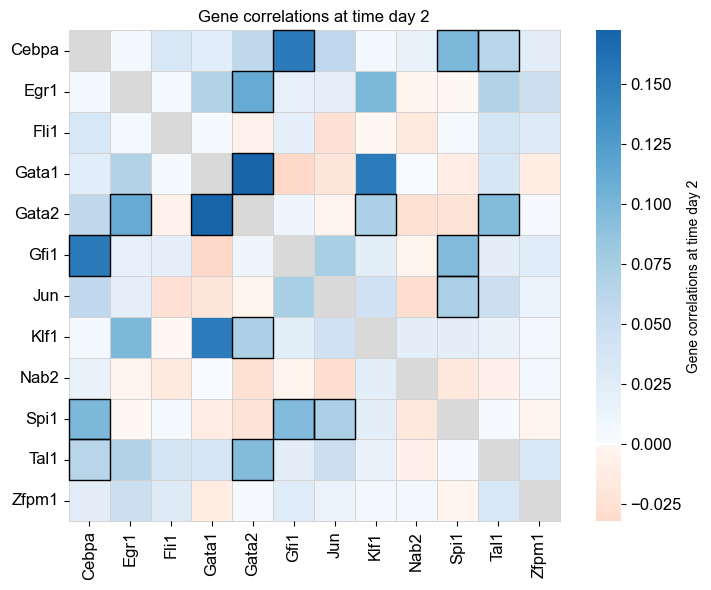

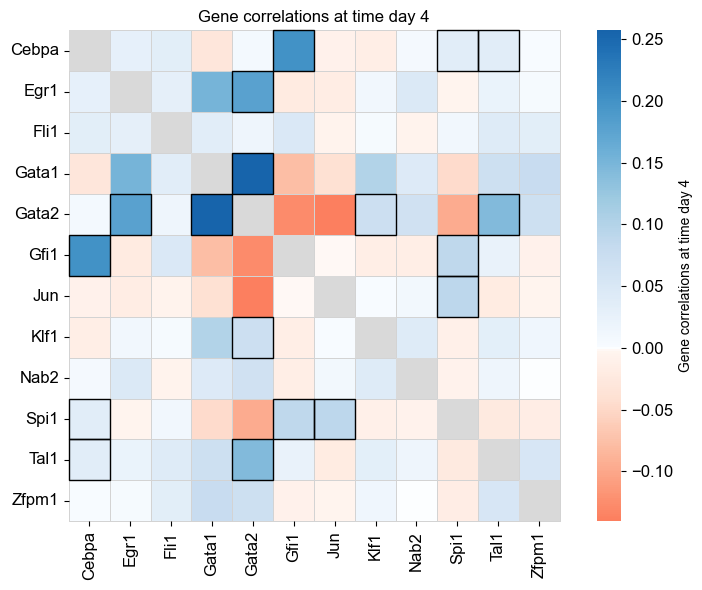

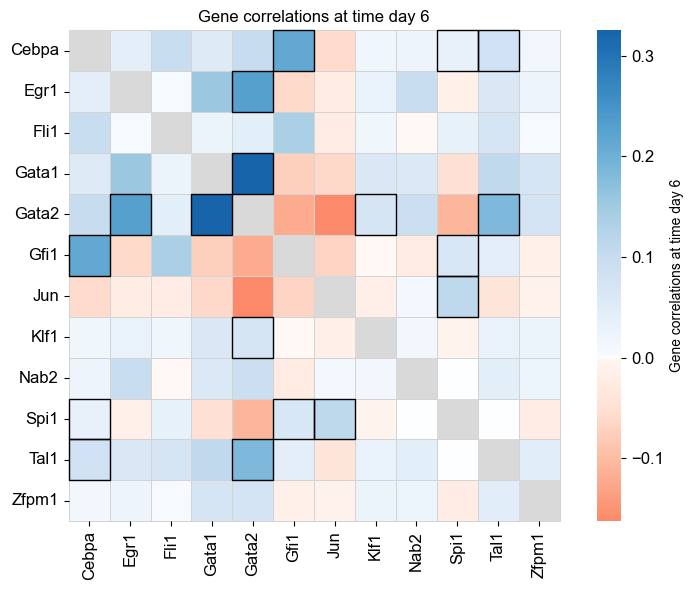

In [35]:
#Plot all 3 timepoints highlight the consistent correlations
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 2", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 4", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 6", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t1)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, potential_regulation_t1, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1, single_state_regulation_t1)


In [ ]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, black_out_self=True
    )

multiple_states_gene_pairs_t2, single_state_regulation_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t2_measurements, potential_regulation_t2, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t2, single_state_regulation_t2)

In [40]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [38]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-potential-regulation"
p_value_threshold_cross_correlation = 0.05
n_cores = 19

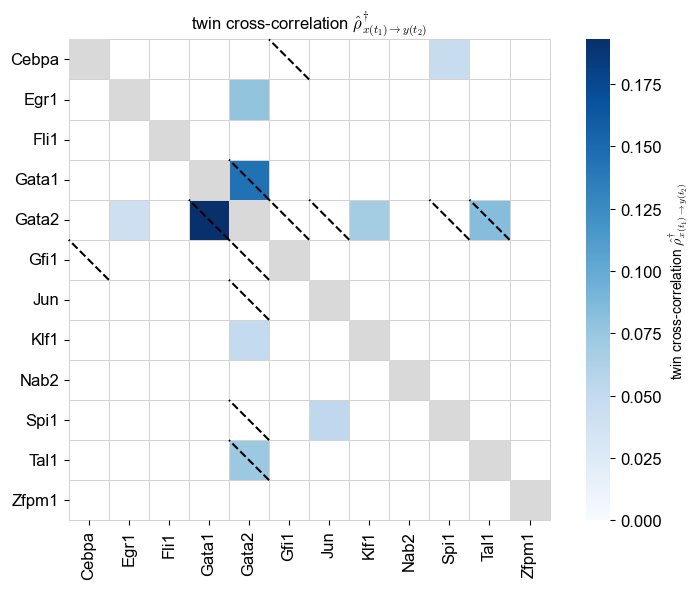

In [45]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-potential-regulation"
p_value_threshold_cross_correlation = 0.05
n_cores = 19

if infer_direction_for_which_edges == "single-state" :
    if len(single_state_regulation_t1) > 0:
        bidirectional_pairs = {(a, b) for (a, b) in single_state_regulation_t1} | \
                  {(b, a) for (a, b) in single_state_regulation_t1}
        # Add self-pairs
        genes = {g for pair in single_state_regulation_t1 for g in pair}
        self_pairs = {(g, g) for g in genes}
        # Final
        all_gene_pairs = bidirectional_pairs | self_pairs
        all_gene_pairs = list(all_gene_pairs)
        direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)

        final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)

elif infer_direction_for_which_edges == "all-potential-regulation":
        if len(consistent_corr) > 0:
                combined_list = consistent_corr
                bidirectional_pairs = {(a, b) for (a, b) in combined_list} | \
                      {(b, a) for (a, b) in combined_list}
                genes = {g for pair in combined_list for g in pair}
                self_pairs = {(g, g) for g in genes}

                # Final
                all_gene_pairs_all_reg = bidirectional_pairs | self_pairs
                all_gene_pairs_all_reg = list(all_gene_pairs_all_reg)

                direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs_all_reg)
                final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs_all_reg, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
        else:
                final_directed_edges = []
                direction_matrix = pd.DataFrame(
                    np.zeros((len(gene_list), len(gene_list))),
                    index=gene_list,
                    columns=gene_list
                )
else:
    print("running all pairs")
    direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
    final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
print(final_directed_edges)
# print(pre_threshold_direction_matrix)
direction_matrix = direction_matrix.reindex(
index=curr_gene_list,
columns=curr_gene_list,
fill_value=0
)
unfiltered_direction_matrix = direction_matrix
if final_directed_edges:
    for i in direction_matrix.index:
        for j in direction_matrix.columns:
            if i != j and (i, j) not in final_directed_edges:
                direction_matrix.loc[i,j] = 0
if plot_correlation_matrices_as_heatmap and not direction_matrix.empty:
      all_gene_pairs = list(product(curr_gene_list, repeat=2))
      no_reg_pairs = [pair for pair in all_gene_pairs if pair not in final_directed_edges]
      if infer_direction_for_which_edges == "all-potential-regulation" and (multiple_states_gene_pairs_t1+multiple_states_gene_pairs_t2):
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False,
              draw_diagonal_multi_state_reg = True,
              multi_state_reg_edges = multiple_states_gene_pairs_t1 + multiple_states_gene_pairs_t2
          )
      else:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False
            )

In [47]:
import json
multiple_states = multiple_states_gene_pairs_t1 + multiple_states_gene_pairs_t2
directional_gene_correlation_data = {
    "gene_list": list(curr_gene_list),
    "corr_matrix": direction_matrix.values.tolist(),
    "no_regulation_pairs": [list(p) for p in no_reg_pairs],
    "final_directed_edges": [list(p) for p in final_directed_edges],
    "multi_state_regulation_pairs": [list(p) for p in multiple_states]
}

with open(f"{path_to_plot_data}/directional_gene_correlation_data.json", "w") as f:
    json.dump(directional_gene_correlation_data, f, indent=2)


## Twinfer analysis - but replacing clonal pairs with random pairs

In [ ]:
#Twin pairs at each time point and across time point
use_undifferentiated = True
if use_undifferentiated:
    adata_t1 = adata_t1_clones_undiff_filter.copy()
else:
    adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()

adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()

# Save cell IDs in .obs
adata_t1.obs['cell_id'] = adata_t1.obs_names
adata_t2.obs['cell_id'] = adata_t2.obs_names
adata_t3.obs['cell_id'] = adata_t3.obs_names

# RANDOMIZATION: Shuffle clone assignments while preserving distribution
np.random.seed(42)  # Set seed for reproducibility, remove or change as needed

def randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3):
    """
    Randomly reassign clone_ids to cells at each timepoint while preserving:
    - Clone size distribution at each timepoint
    - Which clones appear across timepoints (overlap structure)
    """
    # Get original clone IDs and their presence at each timepoint
    clones_t1 = set(adata_t1.obs['clone_id'].unique())
    clones_t2 = set(adata_t2.obs['clone_id'].unique())
    clones_t3 = set(adata_t3.obs['clone_id'].unique())
    
    # Identify clone categories
    all_clones = clones_t1.union(clones_t2).union(clones_t3)
    
    # Map each clone to which timepoints it appears in
    clone_timepoint_map = {}
    for clone_id in all_clones:
        appears_in = []
        if clone_id in clones_t1:
            appears_in.append('t1')
        if clone_id in clones_t2:
            appears_in.append('t2')
        if clone_id in clones_t3:
            appears_in.append('t3')
        clone_timepoint_map[clone_id] = tuple(appears_in)
    
    # Group clones by their timepoint pattern
    pattern_to_clones = {}
    for clone_id, pattern in clone_timepoint_map.items():
        if pattern not in pattern_to_clones:
            pattern_to_clones[pattern] = []
        pattern_to_clones[pattern].append(clone_id)
    
    # For each timepoint, randomize cell assignments within each pattern group
    for adata_t, timepoint in zip([adata_t1, adata_t2, adata_t3], ['t1', 't2', 't3']):
        # Shuffle cells
        shuffled_cells = adata_t.obs_names.to_numpy().copy()
        np.random.shuffle(shuffled_cells)
        
        new_clone_assignments = {}
        cell_idx = 0
        
        # For each pattern that includes this timepoint
        for pattern, clone_list in pattern_to_clones.items():
            if timepoint not in pattern:
                continue
            
            # For each clone in this pattern, assign cells maintaining clone size
            for clone_id in clone_list:
                clone_size = (adata_t.obs['clone_id'] == clone_id).sum()
                cells_for_clone = shuffled_cells[cell_idx:cell_idx + clone_size]
                for cell in cells_for_clone:
                    new_clone_assignments[cell] = clone_id
                cell_idx += clone_size
        
        adata_t.obs['clone_id'] = adata_t.obs_names.map(new_clone_assignments)
    
    return adata_t1, adata_t2, adata_t3

adata_t1, adata_t2, adata_t3 = randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3)

# CHECK: Verify that clonal structure is actually broken
def check_clonal_structure_broken(adata_original, adata_shuffled, timepoint):
    """Check that clone assignments have changed"""
    original_clones = adata_original.obs['clone_id'].values
    shuffled_clones = adata_shuffled.obs['clone_id'].values
    
    # Count how many cells kept their original clone assignment
    matches = (original_clones == shuffled_clones).sum()
    total = len(original_clones)
    match_pct = 100 * matches / total
    
    print(f"{timepoint}: {matches}/{total} cells ({match_pct:.2f}%) kept original clone assignment")
    
    # Check if any cells still have the same clone assignment
    if matches > 0:
        print(f"  WARNING: {matches} cells still in their original clones!")
    else:
        print(f"  ✓ All cells reassigned to different clones")
    
    return match_pct

# Store original clone assignments before randomization
adata_t1_original = adata_t1.copy()
adata_t2_original = adata_t2.copy()
adata_t3_original = adata_t3.copy()

# Note: Need to call randomization here after making copies
adata_t1, adata_t2, adata_t3 = randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3)

print("\n" + "="*60)
print("CLONAL STRUCTURE VERIFICATION")
print("="*60)
check_clonal_structure_broken(adata_t1_original, adata_t1, "t1")
check_clonal_structure_broken(adata_t2_original, adata_t2, "t2")
check_clonal_structure_broken(adata_t3_original, adata_t3, "t3")
print("="*60 + "\n")

# Pick subset of genes
gene_subset = [s + '_mRNA' for s in curr_gene_list]

# Create tables for t1, t2 and t3 twin pairs
for adata_t, timepoint in zip([adata_t1,adata_t2,adata_t3], ['t1','t2', 't3']):
    rows = []
    for clone_id, group in adata_t.obs.groupby('clone_id'):
        cells = group['cell_id'].tolist()
        pair_counter = 0
        for c1, c2 in itertools.combinations(cells, 2):
            pair_id = f"{clone_id}_p{pair_counter}_{timepoint}"
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c1,
                'replicate': 1
            })
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c2,
                'replicate': 2
            })
            pair_counter += 1

    if timepoint == 't1':
        t1_data = pd.DataFrame(rows)
    elif timepoint == 't2':
        t2_data = pd.DataFrame(rows)
    else:
        t3_data = pd.DataFrame(rows)

t1_data['time_step'] = np.repeat(t1, len(t1_data))
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t3_data['time_step'] = np.repeat(t3, len(t3_data))

t1_data[gene_subset] = adata_t1[t1_data.cell_id, curr_gene_list].X.toarray()
t2_data[gene_subset] = adata_t2[t2_data.cell_id, curr_gene_list].X.toarray()
t3_data[gene_subset] = adata_t3[t3_data.cell_id, curr_gene_list].X.toarray()

# ### Create tables for across t twin pairs
across_t_clones = list(set(adata_t1.obs.clone_id).intersection(adata_t2.obs.clone_id))
adata_t1_sub = adata_t1[adata_t1.obs.clone_id.isin(across_t_clones)]
adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]

rows_t1 = []
rows_t2 = []
for clone_id in across_t_clones:
    cells_t1 = adata_t1_sub[adata_t1_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    cells_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    pair_counter = 0
    for cell_t1 in cells_t1:
        for cell_t2 in cells_t2:
            pair_id = f"{clone_id}_p{pair_counter}_across_t"
            rows_t1.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t1,
                'replicate': 1,
                'time_step': t1
            })
            rows_t2.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t2,
                'replicate': 2,
                'time_step': t2
            })

            pair_counter += 1

across_t_data_t1 = pd.DataFrame(rows_t1)
across_t_data_t2 = pd.DataFrame(rows_t2)

across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1.cell_id, curr_gene_list].X.toarray()
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, curr_gene_list].X.toarray()
across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data_t1.shape[0])}")

In [86]:
# Drop column clone_id and rename pair_id to clone_id
t1_data.drop(columns=['clone_id'], inplace=True)
t1_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t2_data.drop(columns=['clone_id'], inplace=True)
t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t3_data.drop(columns=['clone_id'], inplace=True)
t3_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

across_t_data.drop(columns=['clone_id'], inplace=True)
across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t1_clones = t1_data.clone_id.values
t2_clones = t2_data.clone_id.values
t3_clones = t3_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t1_twins = t1_data
t2_twins = t2_data
t3_twins = t3_data

# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = across_t_data[across_t_data.time_step == t1]
across_t_twin2 = across_t_data[across_t_data.time_step == t2]

# Reset index for cleanliness
t1_twins = (
    t1_twins
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)

t2_twins = (
    t2_twins
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)

t3_twins = (
    t3_twins
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)

across_t_twin1 = (
    across_t_twin1
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)

across_t_twin2 = (
    across_t_twin2
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)


all_t1_t2_measurements = pd.concat(
[t1_twins, t2_twins, across_t_twin1, across_t_twin2],
ignore_index=True
)

all_t1_measurements = (
    pd.concat([t1_twins, across_t_twin1], ignore_index=True)
      .drop_duplicates(subset="cell_id", keep="first")
)

all_t2_measurements = (
    pd.concat([t2_twins, across_t_twin2], ignore_index=True)
      .drop_duplicates(subset="cell_id", keep="first")
)

all_t3_measurements = t3_twins

In [ ]:
# === Load saved CSV ===
df = pd.read_csv(path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")

consistent_pairs = (
    set(potential_regulation_t1)
    & set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c1 = pairwise_gene_gene_correlation_matrix_t1.loc[g1, g2]
    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([c1, c2, c3])) or any(c == 0 for c in (c1, c2, c3)):
        continue

    if np.sign(c1) == np.sign(c2) == np.sign(c3):
        consistent_corr.append((g1, g2))
consistent_corr = sorted(consistent_corr)
print(len(consistent_corr))


In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=False, gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, consistent_corr, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1)

In [ ]:
# --- Step 2: Twin/random correlations at day 4 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

In [90]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [ ]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-potential-regulation"
p_value_threshold_cross_correlation = 0.05
n_cores = 19
if infer_direction_for_which_edges == "single-state" :
    if len(single_state_regulation_t1) > 0:
        bidirectional_pairs = {(a, b) for (a, b) in single_state_regulation_t1} | \
                  {(b, a) for (a, b) in single_state_regulation_t1}
        # Add self-pairs
        genes = {g for pair in single_state_regulation_t1 for g in pair}
        self_pairs = {(g, g) for g in genes}
        # Final
        all_gene_pairs = bidirectional_pairs | self_pairs
        all_gene_pairs = list(all_gene_pairs)
        direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)

        final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)

elif infer_direction_for_which_edges == "all-potential-regulation":
        if len(consistent_corr) > 0:
                combined_list = consistent_corr
                bidirectional_pairs = {(a, b) for (a, b) in combined_list} | \
                      {(b, a) for (a, b) in combined_list}
                genes = {g for pair in combined_list for g in pair}
                self_pairs = {(g, g) for g in genes}

                # Final
                all_gene_pairs_all_reg = bidirectional_pairs | self_pairs
                all_gene_pairs_all_reg = list(all_gene_pairs_all_reg)

                direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs_all_reg)
                final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs_all_reg, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
        else:
                final_directed_edges = []
                direction_matrix = pd.DataFrame(
                    np.zeros((len(gene_list), len(gene_list))),
                    index=gene_list,
                    columns=gene_list
                )
else:
    print("running all pairs")
    direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
    final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
print(final_directed_edges)
# print(pre_threshold_direction_matrix)
direction_matrix = direction_matrix.reindex(
index=curr_gene_list,
columns=curr_gene_list,
fill_value=0
)
unfiltered_direction_matrix = direction_matrix
if final_directed_edges:
    for i in direction_matrix.index:
        for j in direction_matrix.columns:
            if i != j and (i, j) not in final_directed_edges:
                direction_matrix.loc[i,j] = 0
if plot_correlation_matrices_as_heatmap and not direction_matrix.empty:
      all_gene_pairs = list(product(curr_gene_list, repeat=2))
      no_reg_pairs = [pair for pair in all_gene_pairs if pair not in final_directed_edges]
      if infer_direction_for_which_edges == "all-potential-regulation" and multiple_states_gene_pairs_t1:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"random cross-correlation $\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False,
              draw_diagonal_multi_state_reg = True,
              multi_state_reg_edges = multiple_states_gene_pairs_t1
          )
      else:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"random cross-correlation $\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False
            )

In [92]:
import json

directional_gene_correlation_data = {
    "gene_list": list(curr_gene_list),
    "corr_matrix": direction_matrix.values.tolist(),
    "no_regulation_pairs": [list(p) for p in no_reg_pairs],
    "final_directed_edges": [list(p) for p in final_directed_edges],
    "multi_state_regulation_pairs": [list(p) for p in multiple_states_and_reg]
}

with open(f"{path_to_plot_data}/random_pair_directional_gene_correlation_data.json", "w") as f:
    json.dump(directional_gene_correlation_data, f, indent=2)
